In [1]:
#Libraries

import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import pandas as pd
from tabulate import tabulate
import scipy.stats as stats
%matplotlib inline
from matplotlib import rc
rc('animation', html='jshtml')
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter, FFMpegWriter


#Basic model

In [2]:
def sir_basic (t,y,beta,gamma):

  s,i,r=y

  #Population
  n=s+i+r

  #Number of people being infected by infected individual r_0>1
  r_0=beta/gamma

  #Average number being infected by infected individual
  reff=(r_0)*(s/n)

  #Differential Equations

  ds = (-beta * (i/n) * s)
  di = (beta * (i/n) * s) - (gamma * i)
  dr = (gamma * i)
  return [ds,di,dr]

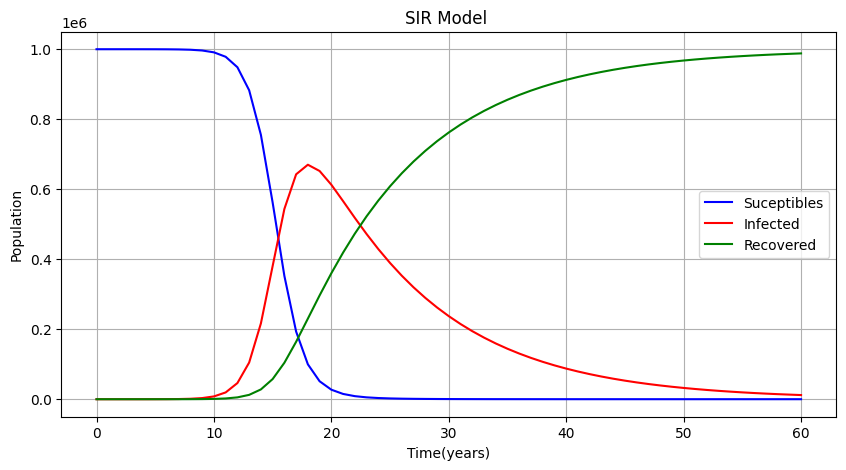

In [3]:

# Initial conditions
y0 = [999999, 1, 0]  # S, I, R

# Time grid
t = np.linspace(0, 60,60).astype(int)

#Parameters
beta=1
gamma=0.1

#Solutions
sol = solve_ivp(sir_basic, [0, 60], y0,args=(beta,gamma),t_eval=t)

#DF
data = pd.DataFrame({
    "Days": sol.t,
    "Suceptibles": sol.y[0],
    "Infected": sol.y[1],
    "Recovered": sol.y[2],})



subset = pd.concat([data.head(5), data.tail(5)])

#print(tabulate(data, headers='keys', tablefmt='grid'))


#plot
plt.figure(figsize=(10,5))
plt.plot(data['Days'],data['Suceptibles'],color='blue')
plt.plot(data['Days'],data['Infected'],color='red')
plt.plot(data['Days'],data['Recovered'],color='green')
plt.xlabel('Time(years)')
plt.ylabel('Population')
plt.title('SIR Model ')
plt.legend(['Suceptibles','Infected','Recovered'])
plt.grid(True)
plt.show()

In [4]:
def sir_non_constant (t,y,beta,gamma,b,mu,v):

  s,i,r=y

  #Population
  n=s+i+r

  #Number of people being infected by infected individual r_0>1
  r_0=beta/gamma

  #Average number being infected by infected individual
  reff=(r_0)*(s/n)

  #Differential Equations

  ds = (-beta * (i/n) * s)  + (b * n) - (mu * s)
  di = (beta * (i/n) * s) - (gamma * i) -(mu*i)
  dr = (gamma * i) - (mu*r)
  return [ds,di,dr]


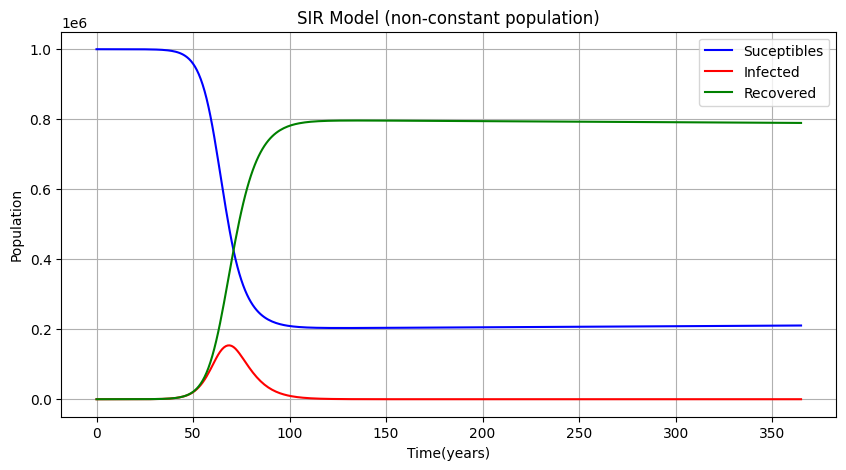

In [5]:

# Initial conditions
y0 = [999999, 1, 0]  # S, I, R

# Time grid
t = np.linspace(0, 365,365).astype(int)


#Parameters
beta=0.4
gamma=0.2
b=1/(70*365)
mu=1/(70*365)
v=0

#Solutions
sol = solve_ivp(sir_non_constant, [0, 365], y0,args=(beta,gamma,b,mu,v),t_eval=t)

#DF
data = pd.DataFrame({
    "Days": sol.t,
    "Suceptibles": sol.y[0],
    "Infected": sol.y[1],
    "Recovered": sol.y[2],})

#print(tabulate(data, headers='keys', tablefmt='grid'))


#plot
plt.figure(figsize=(10,5))
plt.plot(data['Days'],data['Suceptibles'],color='blue')
plt.plot(data['Days'],data['Infected'],color='red')
plt.plot(data['Days'],data['Recovered'],color='green')
plt.xlabel('Time(years)')
plt.ylabel('Population')
plt.title('SIR Model (non-constant population)')
plt.legend(['Suceptibles','Infected','Recovered'])
plt.grid(True)
plt.show()

#Model for vaccination program

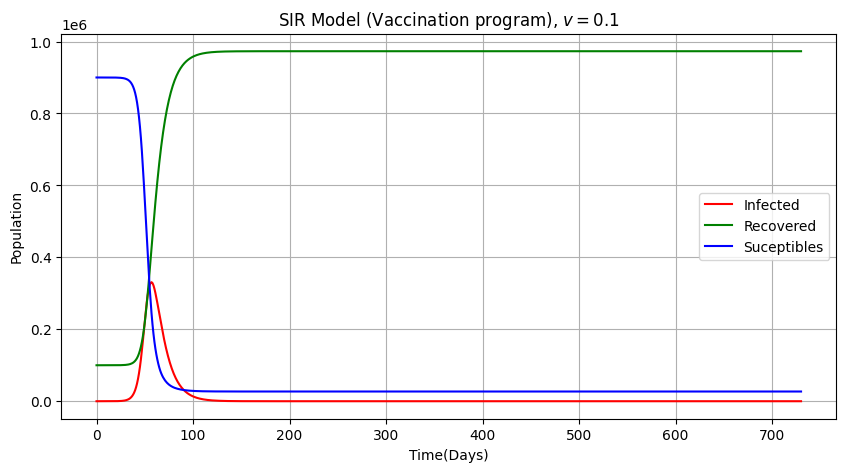

In [6]:


#Parameters

beta=0.4
gamma=0.1
n=1000000
v=0.1
y0=[((1-v)*n),1,v*n]
t=np.linspace(0,730,730).astype(int)

#Solutions

sol= solve_ivp(sir_basic, [0, 730], y0, args=(beta, gamma), t_eval=t)

#DF

data=data = pd.DataFrame({
    "Days": sol.t,
    "Suceptibles": sol.y[0],
    "Infected": sol.y[1],
    "Recovered": sol.y[2],})


#plot

plt.figure(figsize=(10,5))
plt.plot(data['Days'],data['Infected'],color='red')
plt.plot(data['Days'],data['Recovered'],color='green')
plt.plot(data['Days'],data['Suceptibles'],color='blue')
plt.xlabel('Time(Days)')
plt.ylabel('Population')
plt.title(f'SIR Model (Vaccination program), $v={v}$')
plt.legend(['Infected','Recovered','Suceptibles'])
plt.grid(True)
plt.show()



#Part 3

**Problem 1**

Square City (uniform dist)

   ID         X         Y State  Iteration
0   0  3.894871  0.792136     I          0
1   1  3.726328  3.742996     S          0
2   2  1.510765  1.872660     S          0
3   3  3.161971  3.306544     S          0
4   4  2.627963  3.945834     S          0


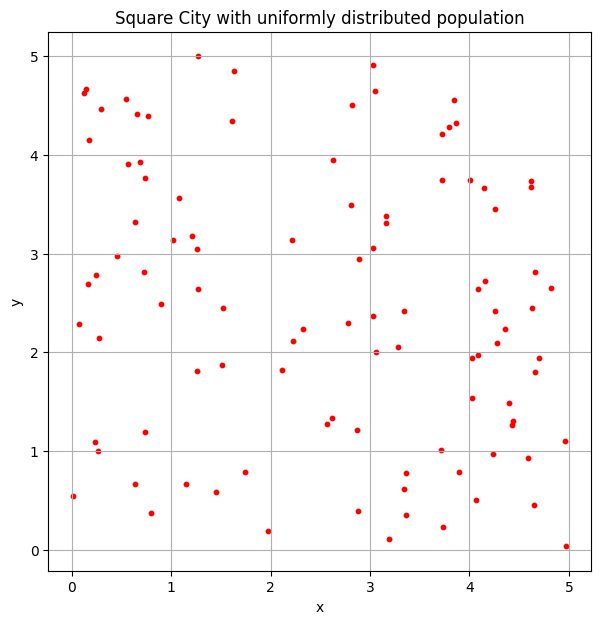

In [7]:
#Population number
n=100

#Dimensions of city
d=5

#Random Coordinates
x_coor=np.random.uniform(0,d,n)
y_coor=np.random.uniform(0,d,n)

#Positions array
positions_array=np.array([x_coor,y_coor])

#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})

print(data.head())


#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Plot
plt.figure(figsize=(7,7))
plt.scatter(x_coor, y_coor, s=10,color='red')
plt.title("Square City with uniformly distributed population")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


**Problem 2**

Circle City (uniform dist)

   ID         X         Y State  Iteration
0   0 -0.499570 -0.712578     I          0
1   1 -1.235376 -0.546858     S          0
2   2  1.577446  1.347714     S          0
3   3 -1.683905 -0.399065     S          0
4   4 -0.420201 -0.770795     S          0


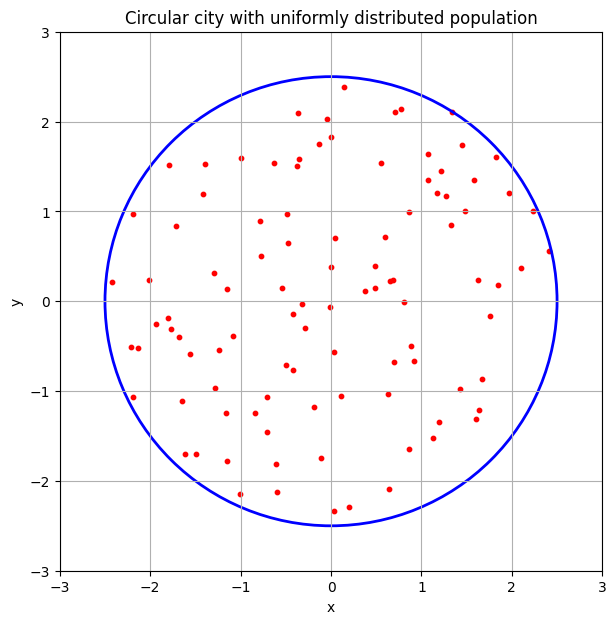

In [8]:
#Population size
n=100

d=5

#Angle
a=np.random.uniform(0,1,n)*(2*np.pi)

#Radius
r=(d/2) * np.sqrt(np.random.uniform(0,1,n))

#Random coordinates
x_coor=r*(np.cos(a))
y_coor=r*(np.sin(a))

#Positions
positions_array=np.array([x_coor,y_coor])


#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})

print(data.head())

#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Plot
circle=plt.Circle((0,0),d/2,color='blue',linewidth=2,fill=False)
plt.figure(figsize=(7,7))
plt.scatter(x_coor, y_coor, s=10,color='red')
plt.gcf().gca().add_artist(circle)
plt.title("Circular city with uniformly distributed population")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.grid(True)
plt.show()



**Problem 3**

Square City (cluster dist)

   ID         X         Y State  Iteration
0   0  1.522423  0.587833     I          0
1   1  0.000000  2.493263     S          0
2   2  0.148224  4.457898     S          0
3   3  0.840597  2.432535     S          0
4   4  0.000000  2.619303     S          0


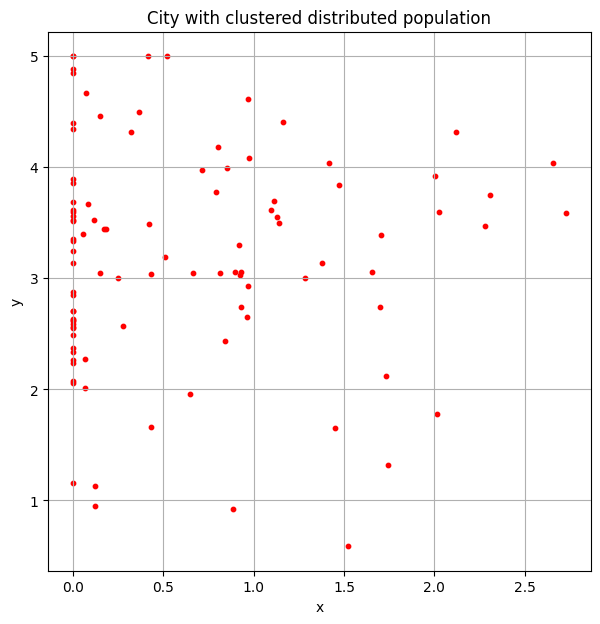

In [9]:
#Population number
n=100

#Dimensions of city
d=5

#Random Coordinates
x0=np.random.uniform(0,d)
y0=np.random.uniform(0,d)
x_coor=np.random.normal(x0,(d/5),n)
y_coor=np.random.normal(y0,(d/5),n)
x_coor = np.clip(x_coor, 0, d)
y_coor = np.clip(y_coor, 0, d)



#Positions array
positions_array=np.array([x_coor,y_coor])



#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})

print(data.head())

#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0




#Plot
plt.figure(figsize=(7,7))
plt.scatter(x_coor, y_coor, s=10,color='red')
plt.title("City with clustered distributed population")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

**Problem 4**

Circular City (cluster dist)

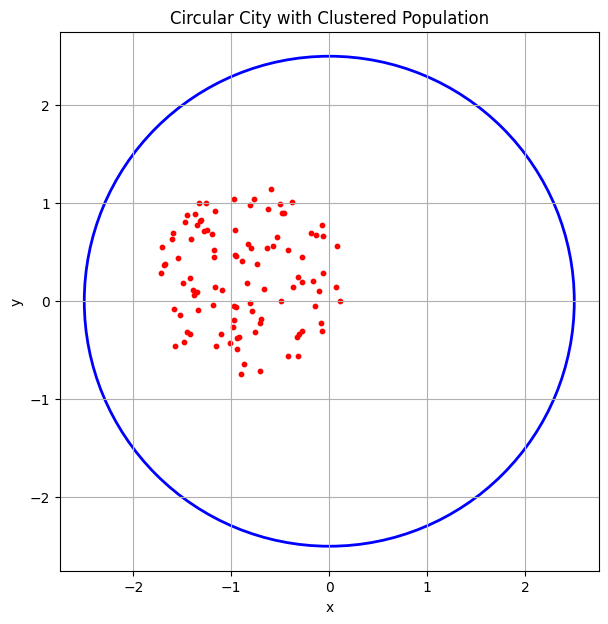

In [10]:
# Parameters
n = 100
d = 5
R = d/2
sigma = d/5


a0 = np.random.uniform(0, 2*np.pi)
r0 = R * np.sqrt(np.random.uniform(0, 1))

x0 = r0 * np.cos(a0)
y0 = r0 * np.sin(a0)

a = np.random.uniform(0, 2*np.pi, n)


r = sigma * np.sqrt(np.random.uniform(0, 1, n))


x = x0 + r * np.cos(a)
y = y0 + r * np.sin(a)


dist = np.sqrt(x**2 + y**2)
outside = dist > R

x[outside] = x[outside] / dist[outside] * R
y[outside] = y[outside] / dist[outside] * R

#Plot
plt.figure(figsize=(7,7))
circle = plt.Circle((0,0), R, fill=False, color='blue', linewidth=2)
plt.gca().add_patch(circle)
plt.scatter(x, y, s=10, color='red')
plt.gca().set_aspect('equal', 'box')
plt.title("Circular City with Clustered Population")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


#Part 4

#Simulation

Square City (uniform dist)

In [11]:
#Simulation parameters
history_x = []
history_y = []
history_state = []

#Population number
n=100

#Dimensions of city
d=5

#Random Coordinates
x_coor=np.random.uniform(0,d,n)
y_coor=np.random.uniform(0,d,n)

#Positions array
positions_array=np.array([x_coor,y_coor])

#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})



#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Iteration Parameters
num_iters = 50
sigma = d/20
data_current=data.copy()

#Loop
for it in range(num_iters):

    data_next=data_current.copy()


    #Movement vectors
    dx = np.random.normal(0, sigma, n)
    dy = np.random.normal(0, sigma, n)

    #New positions
    data_next["X"] += dx
    data_next["Y"] += dy


    data_next["X"] = np.clip(data_next["X"], 0, d)
    data_next["Y"] = np.clip(data_next["Y"], 0, d)


    #Infected and Suceptible DF
    infected = data_current[data_current["State"] == "I"].index
    susceptible = data_current[data_current["State"] == "S"].index

    #Loops to update infected and recovered individuals
    for i in infected:
        xi, yi = data_current.loc[i, ["X", "Y"]]

        for s in susceptible:
            xs, ys = data_current.loc[s, ["X", "Y"]]

            if euc_dist(xi, yi, xs, ys)==1:
                data_next.at[s, 'State'] = "I"


    for i in infected:
        if np.random.random() < rec_rate:
            data_next.at[i, "State"] = "R"

    #Update DF with new values
    data_next['Iteration']=it


    data_current = data_next.copy()

    #Update simulation parameters
    history_x.append(data_current["X"].values.copy())
    history_y.append(data_current["Y"].values.copy())
    history_state.append(data_current["State"].values.copy())


data_current
fig, ax = plt.subplots(figsize=(6,6))


color_map = {
    "S": "blue",
    "I": "red",
    "R": "green"
}


scat = ax.scatter([], [], s=20)

# Plot limits
ax.set_xlim(-1,6)
ax.set_ylim(-1,6)
ax.set_title("Epidemic Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
square = plt.Rectangle((0, 0), d, d, fill=False, color='black', linewidth=2)
ax.add_patch(square)


sus_patch = plt.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Susceptible')
inf_patch = plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Infected')
rec_patch = plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=6, label='Recovered')

ax.legend(handles=[sus_patch, inf_patch, rec_patch], loc='upper right')


def update(frame):
    x = history_x[frame]
    y = history_y[frame]
    states = history_state[frame]

    colors = [color_map[s] for s in states]

    scat.set_offsets(np.column_stack([x, y]))
    scat.set_color(colors)

    ax.set_title(f"Epidemic Simulation (Uniform Square City)")
    return scat,

plt.close(fig)
anim = FuncAnimation(fig, update, frames=len(history_x), interval=150, blit=False)
anim


# --- EXPORT GIF ---
#from matplotlib.animation import PillowWriter

#gif_path = "square_uniform_sim.gif"
#writer = PillowWriter(fps=2)

#anim.save(gif_path, writer=writer)
#print("GIF saved:", gif_path)

# --- DOWNLOAD GIF ---
#from google.colab import files
#files.download(gif_path)







Output hidden; open in https://colab.research.google.com to view.

Circle City (uniform dist)

In [12]:
#Simulation parameters
history_x = []
history_y = []
history_state = []

#Population size
n=100

#Angle
d=5
a=np.random.uniform(0,1,n)*(2*np.pi)

#Radius
R=d/2
r=R * np.sqrt(np.random.uniform(0,1,n))

#Random coordinates
x_coor=r*(np.cos(a))
y_coor=r*(np.sin(a))

#Positions
positions_array=np.array([x_coor,y_coor])


#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})


#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Iteration Parameters
num_iters = 50
sigma = d/20
data_current=data.copy()

#Loop
for it in range(num_iters):

    data_next=data_current.copy()


    #Movement vectors
    dx = np.random.normal(0, sigma, n)
    dy = np.random.normal(0, sigma, n)

    #New positions
    data_next["X"] += dx
    data_next["Y"] += dy


    dist = np.sqrt(data_next["X"]**2 + data_next["Y"]**2)

    # Points outside the circle
    outside = dist > R

    #Move them back to the boundary of the circle (projection)
    data_next.loc[outside, "X"] *= R / dist[outside]
    data_next.loc[outside, "Y"] *= R / dist[outside]


    #Infected and Suceptible DF
    infected = data_current[data_current["State"] == "I"].index
    susceptible = data_current[data_current["State"] == "S"].index

    #Loops to update infected and recovered individuals
    for i in infected:
        xi, yi = data_current.loc[i, ["X", "Y"]]

        for s in susceptible:
            xs, ys = data_current.loc[s, ["X", "Y"]]

            if euc_dist(xi, yi, xs, ys)==1:
                data_next.at[s, 'State'] = "I"


    for i in infected:
        if np.random.random() < rec_rate:
            data_next.at[i, "State"] = "R"

    #Update DF with new values
    data_next['Iteration']=it


    data_current = data_next.copy()

    #Update simulation parameters
    history_x.append(data_current["X"].values.copy())
    history_y.append(data_current["Y"].values.copy())
    history_state.append(data_current["State"].values.copy())


data_current

#Animation
fig, ax = plt.subplots(figsize=(6,6))

color_map = {
    "S": "blue",
    "I": "red",
    "R": "green"
}

scat = ax.scatter([], [], s=20)


ax.set_xlim(-R-1, R+1)
ax.set_ylim((-R)-1, R+1)
ax.set_aspect('equal', 'box')
ax.set_title("Epidemic Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")


circle = plt.Circle((0, 0), R, fill=False, color='black', linewidth=2)
ax.add_patch(circle)


sus_patch = plt.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Susceptible')
inf_patch = plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Infected')
rec_patch = plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=6, label='Recovered')

ax.legend(handles=[sus_patch, inf_patch, rec_patch], loc='upper right')


def update(frame):
    x = history_x[frame]
    y = history_y[frame]
    states = history_state[frame]

    colors = [color_map[s] for s in states]

    scat.set_offsets(np.column_stack([x, y]))
    scat.set_color(colors)

    ax.set_title(f"Epidemic Simulation (Uniform Circular City)")
    return scat,

plt.close(fig)
anim = FuncAnimation(fig, update, frames=len(history_x), interval=150, blit=False)
anim


# --- EXPORT GIF ---
#from matplotlib.animation import PillowWriter

#gif_path = "circular_uniform_sim.gif"
#writer = PillowWriter(fps=2)

#anim.save(gif_path, writer=writer)
#print("GIF saved:", gif_path)

# --- DOWNLOAD GIF ---
#from google.colab import files
#files.download(gif_path)





Output hidden; open in https://colab.research.google.com to view.

Square City (cluster dist)

In [13]:
#Simulation parameters
history_x = []
history_y = []
history_state = []

#Population number
n=100

#Dimensions of city
d=5

#Random Coordinates
x0=np.random.uniform(0,d)
y0=np.random.uniform(0,d)
x_coor=np.random.normal(x0,(d/5),n)
y_coor=np.random.normal(y0,(d/5),n)
x_coor = np.clip(x_coor, 0, d)
y_coor = np.clip(y_coor, 0, d)



#Positions array
positions_array=np.array([x_coor,y_coor])



#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)



#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})



#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Iteration Parameters
num_iters = 50
sigma = d/5
data_current=data.copy()

#Loop
for it in range(num_iters):

    data_next=data_current.copy()


    #Movement vectors
    dx = np.random.normal(0, sigma, n)
    dy = np.random.normal(0, sigma, n)

    #New positions
    data_next["X"] += dx
    data_next["Y"] += dy


    data_next["X"] = np.clip(data_next["X"], 0, d)
    data_next["Y"] = np.clip(data_next["Y"], 0, d)


    #Infected and Suceptible DF
    infected = data_current[data_current["State"] == "I"].index
    susceptible = data_current[data_current["State"] == "S"].index

    #Loops to update infected and recovered individuals
    for i in infected:
        xi, yi = data_current.loc[i, ["X", "Y"]]

        for s in susceptible:
            xs, ys = data_current.loc[s, ["X", "Y"]]

            if euc_dist(xi, yi, xs, ys)==1:
                data_next.at[s, 'State'] = "I"


    for i in infected:
        if np.random.random() < rec_rate:
            data_next.at[i, "State"] = "R"

    #Update DF with new values
    data_next['Iteration']=it


    data_current = data_next.copy()

    #Update simulation parameters
    history_x.append(data_current["X"].values.copy())
    history_y.append(data_current["Y"].values.copy())
    history_state.append(data_current["State"].values.copy())


data_current
fig, ax = plt.subplots(figsize=(6,6))


color_map = {
    "S": "blue",
    "I": "red",
    "R": "green"
}


scat = ax.scatter([], [], s=20)

# Plot limits
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_title("Epidemic Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
square = plt.Rectangle((0, 0), d, d, fill=False, color='black', linewidth=2)
ax.add_patch(square)


sus_patch = plt.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Susceptible')
inf_patch = plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Infected')
rec_patch = plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=6, label='Recovered')

ax.legend(handles=[sus_patch, inf_patch, rec_patch], loc='upper right')


def update(frame):
    x = history_x[frame]
    y = history_y[frame]
    states = history_state[frame]

    colors = [color_map[s] for s in states]

    scat.set_offsets(np.column_stack([x, y]))
    scat.set_color(colors)

    ax.set_title(f"Epidemic Simulation (Clustered Square City)")
    return scat,

plt.close(fig)
anim = FuncAnimation(fig, update, frames=len(history_x), interval=150, blit=False)
anim


# --- EXPORT GIF ---
#from matplotlib.animation import PillowWriter

#gif_path = "square_clustered_sim.gif"
#writer = PillowWriter(fps=2)

#anim.save(gif_path, writer=writer)
#print("GIF saved:", gif_path)

# --- DOWNLOAD GIF ---
#from google.colab import files
#files.download(gif_path)




Circular City (cluster dist)

In [14]:
#Simulation parameters
history_x = []
history_y = []
history_state = []

n = 100
d = 5
R = d/2
sigma = d/5


a0 = np.random.uniform(0, 2*np.pi)
r0 = R * np.sqrt(np.random.uniform(0, 1))

x0 = r0 * np.cos(a0)
y0 = r0 * np.sin(a0)

a = np.random.uniform(0, 2*np.pi, n)


r = sigma * np.sqrt(np.random.uniform(0, 1, n))


x = x0 + r * np.cos(a)
y = y0 + r * np.sin(a)


dist = np.sqrt(x**2 + y**2)
outside = dist > R

x[outside] = x[outside] / dist[outside] * R
y[outside] = y[outside] / dist[outside] * R


#Initial Parameters
inf=1
rec=0
sus=n-(inf+rec)
r_inf=0.6
rec_rate=0.05
state = np.array(["S"] * n)
state[0] = "I"

#Unique id
ids = np.arange(n)

#Iterartion Number
iter_num=np.zeros(n, dtype=int)


#DF
data = pd.DataFrame({
    "ID": ids,
    "X": x_coor,
    "Y": y_coor,
    "State": state,
    "Iteration": iter_num
})


#Euclidean distance

def euc_dist (x1,y1,x2,y2):
  dist=np.sqrt((x1-x2)**2+(y1-y2)**2)

  return 1 if dist<r_inf else 0



#Iteration Parameters
num_iters = 50
sigma = d/5
data_current=data.copy()

#Loop
for it in range(num_iters):

    data_next=data_current.copy()


    #Movement vectors
    dx = np.random.normal(0, sigma, n)
    dy = np.random.normal(0, sigma, n)

    #New positions
    data_next["X"] += dx
    data_next["Y"] += dy


    dist = np.sqrt(data_next["X"]**2 + data_next["Y"]**2)

    # Points outside the circle
    outside = dist > R

    #Move them back to the boundary of the circle (projection)
    data_next.loc[outside, "X"] *= R / dist[outside]
    data_next.loc[outside, "Y"] *= R / dist[outside]


    #Infected and Suceptible DF
    infected = data_current[data_current["State"] == "I"].index
    susceptible = data_current[data_current["State"] == "S"].index

    #Loops to update infected and recovered individuals
    for i in infected:
        xi, yi = data_current.loc[i, ["X", "Y"]]

        for s in susceptible:
            xs, ys = data_current.loc[s, ["X", "Y"]]

            if euc_dist(xi, yi, xs, ys)==1:
                data_next.at[s, 'State'] = "I"


    for i in infected:
        if np.random.random() < rec_rate:
            data_next.at[i, "State"] = "R"

    #Update DF with new values
    data_next['Iteration']=it


    data_current = data_next.copy()

    #Update simulation parameters
    history_x.append(data_current["X"].values.copy())
    history_y.append(data_current["Y"].values.copy())
    history_state.append(data_current["State"].values.copy())


data_current

#Animation
fig, ax = plt.subplots(figsize=(6,6))

color_map = {
    "S": "blue",
    "I": "red",
    "R": "green"
}

scat = ax.scatter([], [], s=20)


ax.set_xlim((-R)-0.2, R+0.2)
ax.set_ylim((-R)-0.2, R+0.2)
ax.set_aspect('equal', 'box')
ax.set_title("Epidemic Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")


circle = plt.Circle((0, 0), R, fill=False, color='black', linewidth=2)
ax.add_patch(circle)


sus_patch = plt.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Susceptible')
inf_patch = plt.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Infected')
rec_patch = plt.Line2D([], [], color='green', marker='o', linestyle='None', markersize=6, label='Recovered')

ax.legend(handles=[sus_patch, inf_patch, rec_patch], loc='upper right')


def update(frame):
    x = history_x[frame]
    y = history_y[frame]
    states = history_state[frame]

    colors = [color_map[s] for s in states]

    scat.set_offsets(np.column_stack([x, y]))
    scat.set_color(colors)

    ax.set_title(f"Epidemic Simulation (Clustered Circular City)")
    return scat,

plt.close(fig)
anim = FuncAnimation(fig, update, frames=len(history_x), interval=150, blit=False)
anim

# --- EXPORT GIF ---
#from matplotlib.animation import PillowWriter

#gif_path = "circular_clustered_city.gif"
#writer = PillowWriter(fps=2)

#anim.save(gif_path, writer=writer)
#print("GIF saved:", gif_path)

# --- DOWNLOAD GIF ---
#from google.colab import files
#files.download(gif_path)




Output hidden; open in https://colab.research.google.com to view.